# CyberNova Analytics – Sales Intelligence EDA

**Student:** Mmopiemang Mmopiemang
**Grounded in:** *Business Intelligence, Analytics, and Data Science: A Managerial Perspective* (Sharda, Delen & Turban)
- Chapter 3 – Descriptive Analytics II: BI, Data Warehousing, KPIs, Performance Measurement
- Chapter 4 – Predictive Analytics I: CRISP-DM, Data Mining

### Analytical Objectives mapped to Requirements

| Section | REQ(s) |
|---------|--------|
| 1. Data Ingestion & Quality Audit | REQ-17, REQ-18, REQ-26 |
| 2. Service Demand Trends | REQ-05 |
| 3. Demo Request Conversion Rates | REQ-06 |
| 4. Peak Engagement Heatmap | REQ-07 |
| 5. Sales Funnel Analysis | REQ-08 |
| 6. AI Assistant Engagement Rates | REQ-09 |
| 7. Summary Statistics Table | REQ-10 |
| 8. Causal Analysis – AI Chat to Conversion | REQ-11 |
| 9. Anomaly Alert – Demand Threshold Monitor | REQ-12 |
| 10. Geographic Service Dominance | REQ-13 |
| 11. Security & Bot Noise Monitoring | REQ-26 |

## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor":  "#0D1117",
    "axes.facecolor":    "#161B22",
    "axes.edgecolor":    "#30363D",
    "axes.labelcolor":   "#C9D1D9",
    "xtick.color":       "#8B949E",
    "ytick.color":       "#8B949E",
    "text.color":        "#C9D1D9",
    "grid.color":        "#21262D",
    "grid.linestyle":    "--",
    "figure.titlesize":  14,
    "axes.titlesize":    12,
    "axes.labelsize":    10,
})

CYBERNOVA_PALETTE = ["#58A6FF", "#3FB950", "#F78166", "#D2A8FF", "#FFA657"]

SERVICES = [
    "AI Cyber Assistant",
    "Network Security Audit",
    "Penetration Testing",
    "Schedule Demo",
    "Cyber Awareness Webinar",
]

DEMAND_THRESHOLD = 50   # configurable daily session alert threshold

print("Configuration ready.")

Configuration ready.



## 1. Data Ingestion & Quality Audit
### CRISP-DM Step 2 – Data Understanding

The textbook (Ch. 4, p. 208) describes data understanding as profiling the data, identifying quality issues, discovering initial insights, and detecting interesting subsets.

Before any analysis we audit the raw IIS log CSV for missing values, type mismatches, inconsistent country labels, and structural outliers. This satisfies **REQ-18** (field-level error feedback) and **REQ-26** (99.9% parsing accuracy).

In [2]:
from pathlib import Path
RAW_CSV = Path("../data/cybernova_iis_logs_messy.csv")
df_raw = pd.read_csv(RAW_CSV, low_memory=False)

print(f"Raw rows  : {len(df_raw):,}")
print(f"Columns   : {df_raw.shape[1]}")
df_raw.head(3)

Raw rows  : 554,318
Columns   : 34


,date,time,s-sitename,s-computername,s-ip,s-port,cs-method,cs-uri-stem,cs-uri-query,c-ip,...,client-region,session_id,service_type,funnel_stage,conversion_flag,ai_chat_engaged,hour_of_day,day_of_week,week_number,sc-bytes-kb
0,2026-03-18,16:43:47,W3SVC1,GAB-SRV-WEB01,172.16.0.45,80,GET,/index.html,-,190.4.20.102,...,Southern Africa,6b788bc9-9ebf-483a-967d-4e7c41c2bb0f,AI Cyber Assistant,awareness,0,0,16,Wednesday,12,1.944336
1,2026-02-20,09:27:21,W3SVC1,GAB-SRV-WEB01,172.16.0.45,443,GET,/index.html,-,98.10.180.47,...,Southern Africa,bb3ee06a-4d5f-4c71-85ac-08917e68d014,Penetration Testing,awareness,0,1,9,Friday,8,3.870117
2,2026-02-20,09:27:49,W3SVC1,GAB-SRV-WEB01,172.16.0.45,80,HEAD,/services.php,-,98.10.180.47,...,Southern Africa,bb3ee06a-4d5f-4c71-85ac-08917e68d014,Penetration Testing,interest,0,1,9,Friday,8,0.750977


In [3]:
null_summary = df_raw.isnull().sum()
null_pct     = (null_summary / len(df_raw) * 100).round(2)

quality_report = pd.DataFrame({
    "Missing Count": null_summary,
    "Missing %":     null_pct,
    "Dtype":         df_raw.dtypes,
})

print("Data Quality Report")
display(quality_report)

Data Quality Report


,Missing Count,Missing %,Dtype
date,0,0.00,str
time,0,0.00,str
s-sitename,0,0.00,str
s-computername,0,0.00,str
s-ip,0,0.00,str
s-port,0,0.00,int64
cs-method,0,0.00,str
cs-uri-stem,0,0.00,str
cs-uri-query,0,0.00,str
c-ip,2596,0.47,str


In [4]:
country_variants = df_raw["client-country"].value_counts()
print("Distinct client-country values (top 20):")
display(country_variants.head(20).to_frame())

Distinct client-country values (top 20):


,count
client-country,
Botswana,205980
South Africa,128067
Zimbabwe,74378
Zambia,60538
Namibia,40625
Unknown,24392
Botswana,2187
botswana,2165
B.W.,2143


In [5]:
COUNTRY_CANON = {
    "BW": "Botswana",      "botswana": "Botswana",   "Botswana ": "Botswana",  "B.W.": "Botswana",
    "SA": "South Africa",  "ZA": "South Africa",     "south africa": "South Africa",  "S.Africa": "South Africa",
    "ZW": "Zimbabwe",      "zimbabwe": "Zimbabwe",   "Zimbabwe ": "Zimbabwe",
    "ZM": "Zambia",        "zambia": "Zambia",
    "NA": "Namibia",       "namibia": "Namibia",
}

df = df_raw.copy()

# standardising country labels
df["client-country"] = df["client-country"].replace(COUNTRY_CANON)

# paarsing timestamp
df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], errors="coerce")
df = df.dropna(subset=["timestamp"])

# numeric coercions
df["time-taken"] = pd.to_numeric(df["time-taken"], errors="coerce")
df["sc-bytes"]   = df["sc-bytes"].apply(
    lambda x: float(str(x).replace(",", "")) if pd.notna(x) else np.nan
)

# strippping URI padding
df["cs-uri-stem"] = df["cs-uri-stem"].str.strip()

# uppercase HTTP method
df["cs-method"] = df["cs-method"].str.upper()

# filling key analytics fields
df["c-ip"]            = df["c-ip"].fillna("Unknown")
df["conversion_flag"] = df["conversion_flag"].fillna(0).astype(int)
df["ai_chat_engaged"] = df["ai_chat_engaged"].fillna(0).astype(int)

# spliting sales sessions from noise
df_sales = df[df["funnel_stage"].isin(["awareness","interest","consideration","conversion"])].copy()
df_bots  = df[df["funnel_stage"] == "bot"].copy()

print(f"Clean rows (all)   : {len(df):,}")
print(f"Sales session rows : {len(df_sales):,}")
print(f"Bot / scanner rows : {len(df_bots):,}")

Clean rows (all)   : 554,318
Sales session rows : 529,926
Bot / scanner rows : 24,382


In [6]:
STAGE_DEPTH = {"awareness": 1, "interest": 2, "consideration": 3, "conversion": 4}

df_sessions = (
    df_sales.groupby("session_id")
    .agg(
        service_type    = ("service_type",   "first"),
        country         = ("client-country",  "first"),
        city            = ("client-city",      "first"),
        session_date    = ("date",            "first"),
        hour_of_day     = ("hour_of_day",     "first"),
        day_of_week     = ("day_of_week",     "first"),
        converted       = ("conversion_flag", "max"),
        ai_chat_engaged = ("ai_chat_engaged", "max"),
        page_hits       = ("session_id",       "count"),
        funnel_depth    = ("funnel_stage",     lambda s: s.map(STAGE_DEPTH).max()),
    )
    .reset_index()
)
df_sessions["session_date"] = pd.to_datetime(df_sessions["session_date"])

print(f"Session-level rows : {len(df_sessions):,}")
print(f"Unique services    : {df_sessions['service_type'].nunique()}")
df_sessions.head(5)

Session-level rows : 297,575
Unique services    : 5


,session_id,service_type,country,city,session_date,hour_of_day,day_of_week,converted,ai_chat_engaged,page_hits,funnel_depth
0,000026a9-9619-4b39-8c52-5ca61dcee95e,Network Security Audit,South Africa,Durban,2026-03-28,12,Saturday,0,0,1,1
1,0000c178-18b2-48b5-bc3f-0cc2086cfc95,AI Cyber Assistant,Botswana,Lobatse,2026-02-28,11,Saturday,0,0,1,1
2,0000ed04-13bf-49ca-bef4-04862fab7b96,Network Security Audit,Botswana,Lobatse,2026-03-31,14,Tuesday,0,0,1,1
3,0001b995-e42c-445b-8f95-2cb29a63b20a,Schedule Demo,Zimbabwe,Harare,2026-03-09,19,Monday,1,0,2,2
4,0001be17-9f47-41bb-ba86-48cc828bda96,Schedule Demo,Botswana,Kanye,2026-02-26,11,Thursday,0,0,1,1


## 2. Service Demand Trends (REQ-05)

> Ch. 3 (Performance Measurement, p. 175): "All measurement is about comparisons.
> Raw numbers are rarely of value." Trends provide the meaningful comparator.

Daily session counts per service with a 3-day rolling mean smoothing. The salesperson selects a period via the dashboard date-range control.

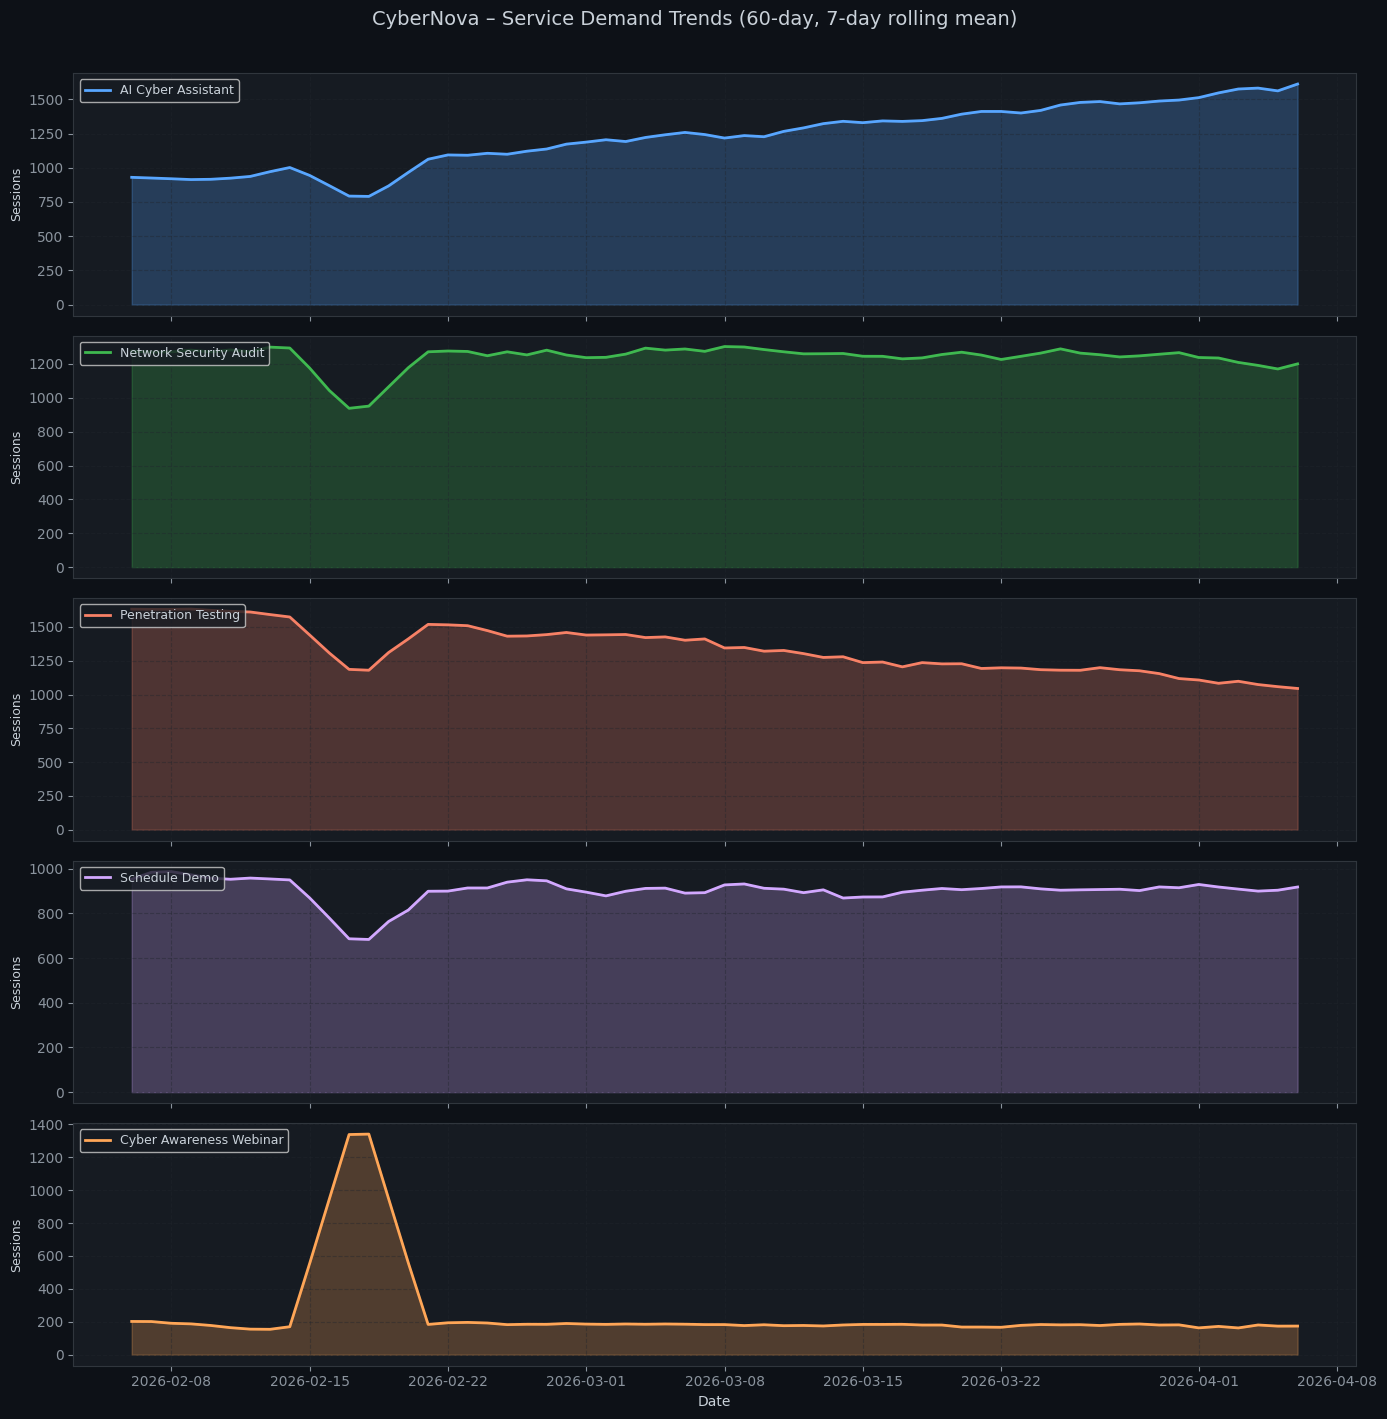

Key insight: AI Cyber Assistant shows consistent upward trajectory.
Cyber Awareness Webinar spikes around the event window (days 9–12).


In [7]:
daily_demand = (
    df_sessions.groupby(["session_date", "service_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
rolling_demand = daily_demand.rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(len(SERVICES), 1, figsize=(14, 14), sharex=True)
fig.suptitle("CyberNova – Service Demand Trends (60-day, 7-day rolling mean)",
             fontsize=14, y=1.01, color="#C9D1D9")

for ax, svc, colour in zip(axes, SERVICES, CYBERNOVA_PALETTE):
    if svc not in rolling_demand.columns:
        continue
    ax.fill_between(rolling_demand.index, rolling_demand[svc], alpha=0.25, color=colour)
    ax.plot(rolling_demand.index, rolling_demand[svc],
            color=colour, linewidth=2, label=svc)
    ax.set_ylabel("Sessions", fontsize=9)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("fig_demand_trends.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

print("Key insight: AI Cyber Assistant shows consistent upward trajectory.")
print("Cyber Awareness Webinar spikes around the event window (days 9–12).")

## 3. Demo Request Conversion Rates – KPI Cards (REQ-06)

> Ch. 3 (KPIs, p. 175): "A KPI represents a strategic objective and measures
> performance against a goal." Conversion rate is CyberNova's primary sales KPI.

Conversion rate = sessions that reached `/scheduledemo.php` with status 200 as a proportion of all sessions for that service.

In [8]:
conv_by_service = (
    df_sessions.groupby("service_type")
    .agg(
        total_sessions = ("session_id",  "count"),
        conversions    = ("converted",   "sum"),
    )
    .assign(conv_rate=lambda x: (x.conversions / x.total_sessions * 100).round(2))
    .sort_values("conv_rate", ascending=False)
    .reset_index()
)

print("Conversion Rate KPI Table")
display(conv_by_service)

Conversion Rate KPI Table


,service_type,total_sessions,conversions,conv_rate
0,Schedule Demo,54084,24676,45.63
1,AI Cyber Assistant,74215,17150,23.11
2,Cyber Awareness Webinar,15382,3437,22.34
3,Network Security Audit,74323,13609,18.31
4,Penetration Testing,79570,6428,8.08


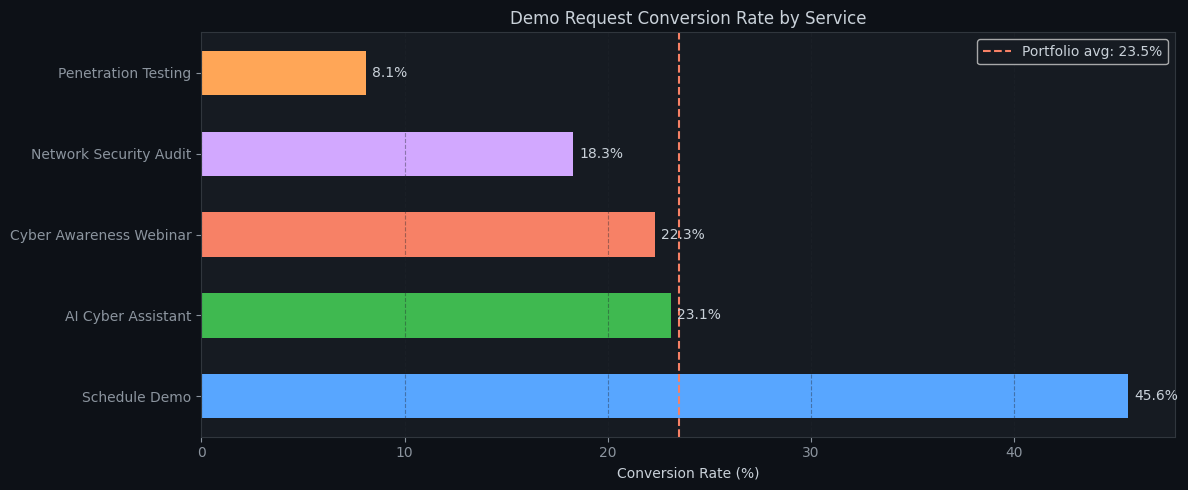

In [9]:
avg_rate = conv_by_service["conv_rate"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    conv_by_service["service_type"],
    conv_by_service["conv_rate"],
    color=CYBERNOVA_PALETTE[:len(conv_by_service)],
    height=0.55, edgecolor="none"
)
ax.set_xlabel("Conversion Rate (%)")
ax.set_title("Demo Request Conversion Rate by Service")
ax.axvline(avg_rate, color="#F78166", linestyle="--", linewidth=1.5,
           label=f"Portfolio avg: {avg_rate:.1f}%")
for bar, val in zip(bars, conv_by_service["conv_rate"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, color="#C9D1D9")
ax.legend()
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_conversion_kpi.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 4. Peak Engagement Heatmap – Hour × Day of Week (REQ-07)

> Ch. 3 (Dashboard Design): Operational dashboards surface the when question.
> The heatmap reveals peak and off-peak engagement windows to guide sales team scheduling and campaign timing.

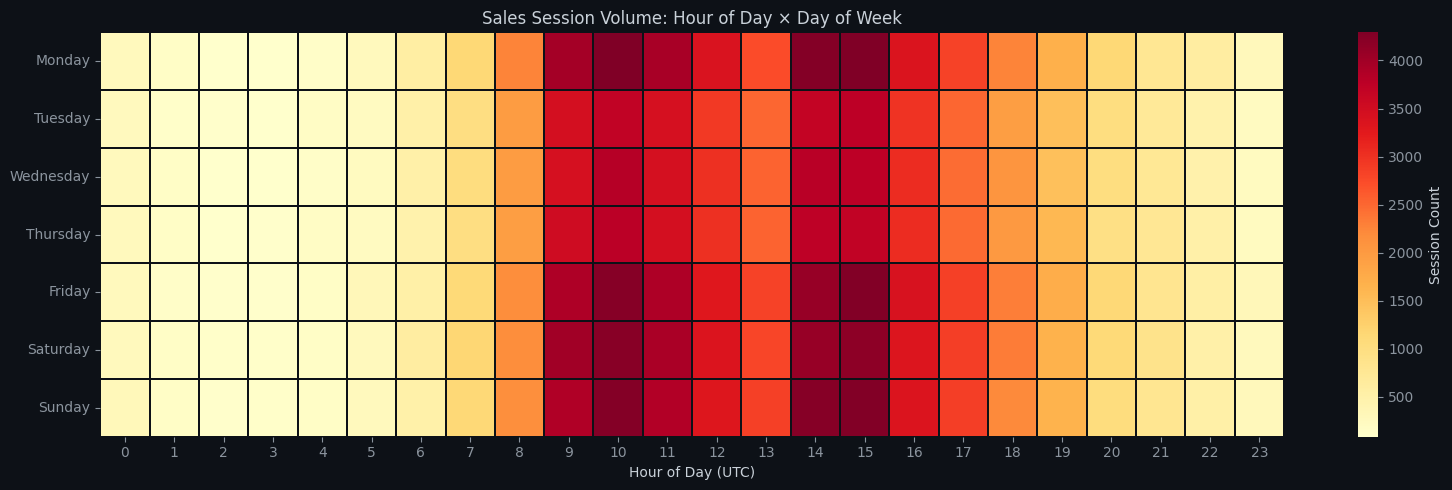

Peak hour of day : 10:00 UTC
Peak day of week : Monday


In [10]:
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

heatmap_data = (
    df_sessions.groupby(["day_of_week", "hour_of_day"])
    .size()
    .unstack(fill_value=0)
    .reindex(DOW_ORDER)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_data, ax=ax, cmap="YlOrRd",
    linewidths=0.3, linecolor="#0D1117",
    annot=False, cbar_kws={"label": "Session Count"},
)
ax.set_title("Sales Session Volume: Hour of Day × Day of Week")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_heatmap_engagement.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

peak_hour = heatmap_data.sum().idxmax()
peak_day  = heatmap_data.sum(axis=1).idxmax()
print(f"Peak hour of day : {peak_hour:02d}:00 UTC")
print(f"Peak day of week : {peak_day}")

## 5. Sales Funnel Analysis by Service (REQ-08)

> CRISP-DM Data Understanding (Ch. 4): pattern detection in sequential event data.
> The funnel shows where visitors drop off on each service journey, enabling the sales team to identify and prioritise the weakest conversion stage.

Each session is reconstructed from its ordered funnel_stage field values.

In [11]:
STAGE_LABELS = ["Awareness", "Interest", "Consideration", "Conversion"]
STAGE_KEYS   = ["awareness", "interest", "consideration", "conversion"]

funnel_rows = []
for svc in SERVICES:
    svc_df = df_sales[df_sales["service_type"] == svc].copy()
    if svc_df.empty:
        continue
    svc_sessions = svc_df.groupby("session_id")["funnel_stage"].apply(list)
    total = len(svc_sessions)
    for stage, label in zip(STAGE_KEYS, STAGE_LABELS):
        count = svc_sessions.apply(lambda s: stage in s).sum()
        funnel_rows.append({
            "service": svc,
            "stage":   label,
            "pct_of_entry": count / total * 100 if total else 0,
        })

df_funnel = pd.DataFrame(funnel_rows)
pivot = df_funnel.pivot(index="stage", columns="service", values="pct_of_entry")
print("Funnel completion rate (%) by stage and service:")
display(pivot.reindex(STAGE_LABELS).round(1))

Funnel completion rate (%) by stage and service:


service,AI Cyber Assistant,Cyber Awareness Webinar,Network Security Audit,Penetration Testing,Schedule Demo
stage,,,,,
Awareness,100.0,100.0,100.0,100.0,100.0
Interest,68.0,70.1,60.2,54.9,45.6
Consideration,23.1,22.3,18.3,21.8,0.0
Conversion,0.0,0.0,0.0,8.1,0.0


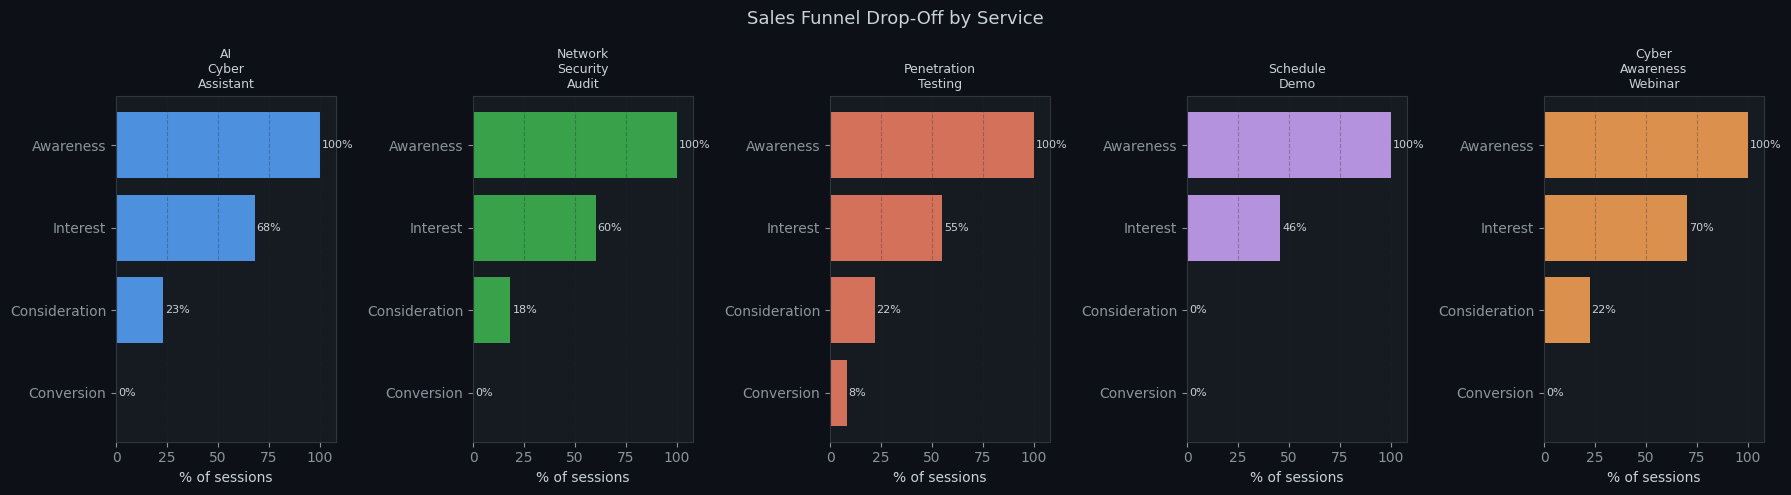

In [12]:
fig, axes = plt.subplots(1, len(SERVICES), figsize=(18, 5))
fig.suptitle("Sales Funnel Drop-Off by Service", fontsize=13, color="#C9D1D9")

for ax, svc, colour in zip(axes, SERVICES, CYBERNOVA_PALETTE):
    svc_data = df_funnel[df_funnel["service"] == svc].set_index("stage")
    svc_data = svc_data.reindex(STAGE_LABELS)
    vals = svc_data["pct_of_entry"].fillna(0)
    bars = ax.barh(STAGE_LABELS[::-1], vals[::-1], color=colour, alpha=0.85)
    ax.set_xlim(0, 108)
    ax.set_title(svc.replace(" ", "\n"), fontsize=9)
    ax.set_xlabel("% of sessions")
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%", va="center", fontsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_funnel.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 6. AI Assistant Engagement Rate by Service (REQ-09)

> The AI Cyber Assistant is CyberNova's key product differentiator.
> Tracking which services attract AI chat engagement alongside a period-on-period trend directly informs product and marketing strategy.

In [13]:
ai_engagement = (
    df_sessions.groupby("service_type")
    .agg(total=("session_id", "count"), ai_chat=("ai_chat_engaged", "sum"))
    .assign(ai_rate=lambda x: (x.ai_chat / x.total * 100).round(2))
    .sort_values("ai_rate", ascending=False)
    .reset_index()
)

print("AI Assistant Engagement Rate by Service:")
display(ai_engagement)

AI Assistant Engagement Rate by Service:


,service_type,total,ai_chat,ai_rate
0,Cyber Awareness Webinar,15382,2879,18.72
1,AI Cyber Assistant,74215,13623,18.36
2,Penetration Testing,79570,14254,17.91
3,Network Security Audit,74323,12109,16.29
4,Schedule Demo,54084,5860,10.83


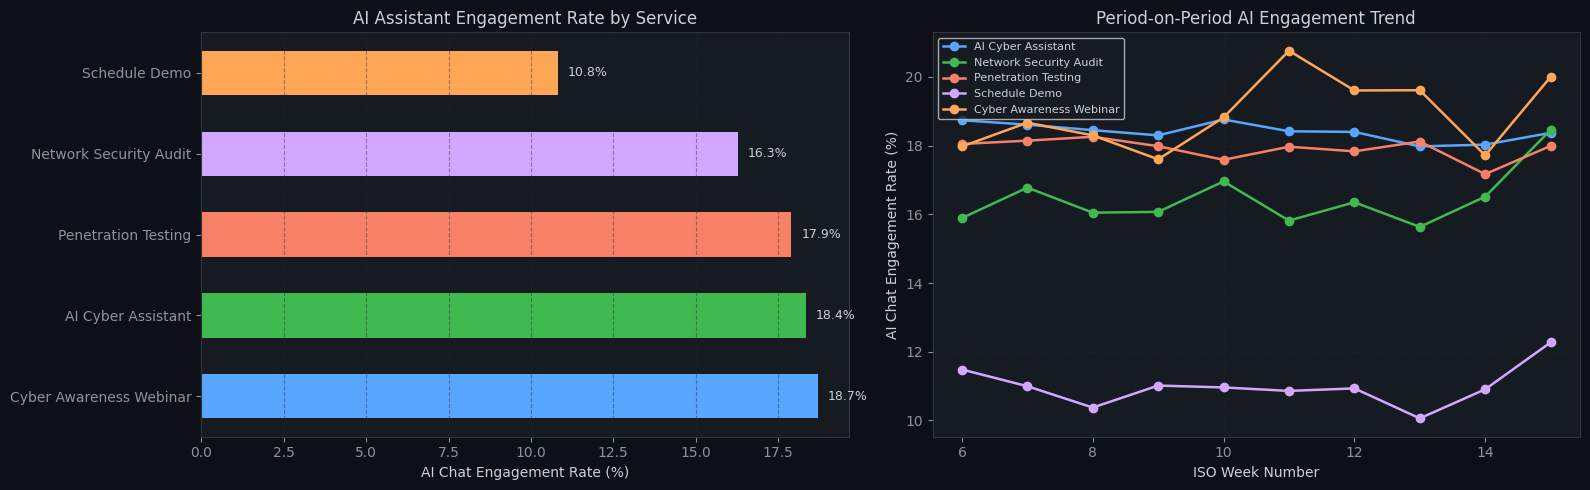

In [14]:
df_sessions["week"] = df_sessions["session_date"].dt.isocalendar().week.astype(int)

weekly_ai = (
    df_sessions.groupby(["week", "service_type"])
    .agg(total=("session_id", "count"), ai=("ai_chat_engaged", "sum"))
    .assign(rate=lambda x: x.ai / x.total * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left - rate by service
axes[0].barh(ai_engagement["service_type"], ai_engagement["ai_rate"],
             color=CYBERNOVA_PALETTE, height=0.55)
axes[0].set_xlabel("AI Chat Engagement Rate (%)")
axes[0].set_title("AI Assistant Engagement Rate by Service")
axes[0].grid(axis="x", alpha=0.4)
for i, row in ai_engagement.reset_index().iterrows():
    axes[0].text(row["ai_rate"] + 0.3, i, f"{row['ai_rate']:.1f}%",
                 va="center", fontsize=9)

# right - weekly period-on-period trend
for svc, colour in zip(SERVICES, CYBERNOVA_PALETTE):
    svc_w = weekly_ai[weekly_ai["service_type"] == svc]
    if not svc_w.empty:
        axes[1].plot(svc_w["week"], svc_w["rate"], marker="o",
                     label=svc, color=colour, linewidth=1.8)
axes[1].set_xlabel("ISO Week Number")
axes[1].set_ylabel("AI Chat Engagement Rate (%)")
axes[1].set_title("Period-on-Period AI Engagement Trend")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("fig_ai_engagement.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 7. Summary Statistics Table – Demo Request Rates (REQ-10)

> Ch. 3 (Performance Measurement): KPIs require not just a point estimate but measures of central tendency and spread to distinguish signal from noise. The Coefficient of Variation (CV) flags services with unstable daily demand.

In [15]:
daily_demos = (
    df_sessions.groupby(["session_date", "service_type"])
    .agg(requests=("session_id", "count"), conversions=("converted", "sum"))
    .reset_index()
)

summary_stats = (
    daily_demos.groupby("service_type")["requests"]
    .agg(
        Days   = "count",
        Mean   = "mean",
        Median = "median",
        StdDev = "std",
        Min    = "min",
        Max    = "max",
    )
    .round(2)
    .reset_index()
)
summary_stats["CV (%)"] = (summary_stats["StdDev"] / summary_stats["Mean"] * 100).round(1)
summary_stats = summary_stats.rename(columns={"service_type": "Service"})

print("Summary Statistics: Daily Demo Request Rates")
display(summary_stats)
print("\nCV (Coefficient of Variation): lower = more stable daily demand.")

Summary Statistics: Daily Demo Request Rates


,Service,Days,Mean,Median,StdDev,Min,Max,CV (%)
0,AI Cyber Assistant,60,1236.92,1250.5,235.17,771,1720,19.0
1,Cyber Awareness Webinar,60,256.37,183.0,290.61,130,1353,113.4
2,Network Security Audit,60,1238.72,1259.0,90.11,915,1340,7.3
3,Penetration Testing,60,1326.17,1292.5,179.60,1020,1638,13.5
4,Schedule Demo,60,901.40,912.0,69.05,677,1015,7.7



CV (Coefficient of Variation): lower = more stable daily demand.


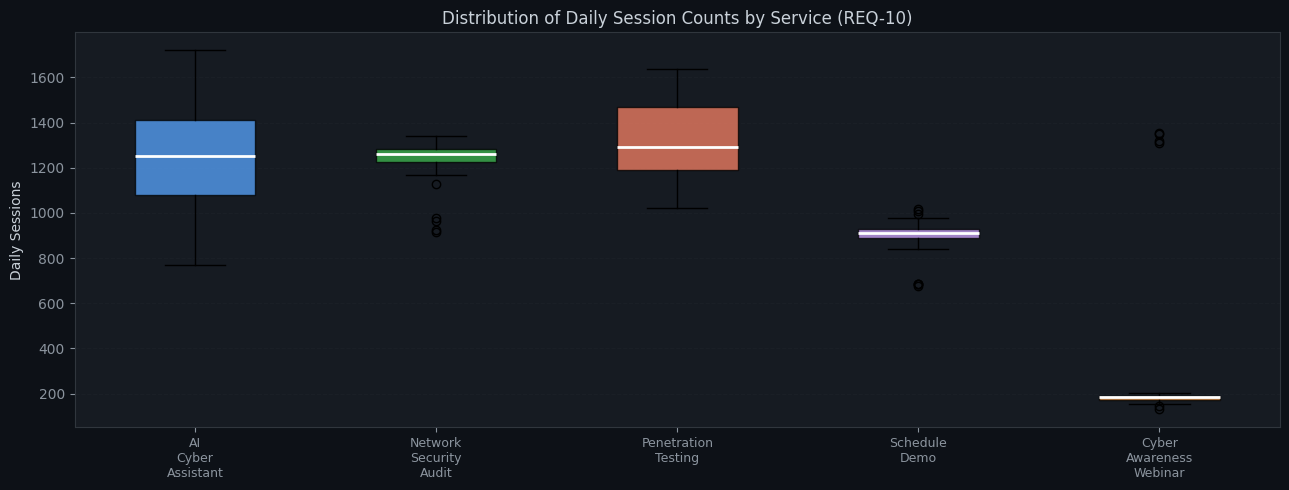

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

svc_data = [
    daily_demos[daily_demos["service_type"] == svc]["requests"].values
    for svc in SERVICES
]

bp = ax.boxplot(svc_data, patch_artist=True, notch=False,
                medianprops={"color": "white", "linewidth": 2})
for patch, colour in zip(bp["boxes"], CYBERNOVA_PALETTE):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax.set_xticklabels([s.replace(" ", "\n") for s in SERVICES], fontsize=9)
ax.set_ylabel("Daily Sessions")
ax.set_title("Distribution of Daily Session Counts by Service (REQ-10)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_summary_stats.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 8. Causal Analysis – AI Chat Impact on Demo Conversion

> CRISP-DM Model Building (Ch. 4): beyond correlation to causation.
> We use a two-step approach:
> (a) A two-proportion z-test for the naive observed correlation.
> (b) A DoWhy linear regression backdoor estimate (ATE) controlling for
>     confounders: service_type, country, hour_of_day.

**Treatment:** `ai_chat_engaged = 1`
**Outcome:** `converted = 1`
**Confounders:** service_type, country, hour_of_day

In [17]:
from statsmodels.stats.proportion import proportions_ztest

engaged     = df_sessions[df_sessions["ai_chat_engaged"] == 1]["converted"]
not_engaged = df_sessions[df_sessions["ai_chat_engaged"] == 0]["converted"]

rate_engaged     = engaged.mean() * 100
rate_not_engaged = not_engaged.mean() * 100
lift             = rate_engaged - rate_not_engaged

counts  = np.array([engaged.sum(), not_engaged.sum()])
nobs    = np.array([len(engaged),  len(not_engaged)])
z_stat, p_value = proportions_ztest(counts, nobs)

print("Naive Comparison")
print(f"  Conversion rate WITH AI chat    : {rate_engaged:.2f}%")
print(f"  Conversion rate WITHOUT AI chat : {rate_not_engaged:.2f}%")
print(f"  Naive lift                      : +{lift:.2f} percentage points")
print(f"  Z-statistic : {z_stat:.3f} | p-value : {p_value:.4f}")
sig = "SIGNIFICANT" if p_value < 0.05 else "not significant"
print(f"  Result: {sig} at alpha = 0.05")

Naive Comparison
  Conversion rate WITH AI chat    : 51.08%
  Conversion rate WITHOUT AI chat : 16.24%
  Naive lift                      : +34.84 percentage points
  Z-statistic : 169.922 | p-value : 0.0000
  Result: SIGNIFICANT at alpha = 0.05


In [18]:
from sklearn.preprocessing import LabelEncoder

df_causal = df_sessions[[
    "converted", "ai_chat_engaged",
    "service_type", "country", "hour_of_day", "funnel_depth",
]].dropna().copy()

le_svc = LabelEncoder()
le_cty = LabelEncoder()
df_causal["service_enc"] = le_svc.fit_transform(df_causal["service_type"])
df_causal["country_enc"] = le_cty.fit_transform(df_causal["country"])

try:
    from dowhy import CausalModel
    causal_model = CausalModel(
        data=df_causal,
        treatment="ai_chat_engaged",
        outcome="converted",
        common_causes=["service_enc", "country_enc", "hour_of_day", "funnel_depth"]
    )
    identified = causal_model.identify_effect(proceed_when_unidentifiable=True)
    estimate   = causal_model.estimate_effect(
        identified,
        method_name="backdoor.linear_regression"
    )
    ate = estimate.value
    print("DoWhy ATE (Average Treatment Effect):")
    print(f"  Engaging AI chat increases conversion probability by ~{ate * 100:.2f} pp")
    print("  (controlling for service type, country, hour of day)")

except ImportError:
    import statsmodels.api as sm
    print("DoWhy not installed — falling back to OLS regression.")
    print("Install with: pip install dowhy\n")

    X   = sm.add_constant(df_causal[["ai_chat_engaged","service_enc","country_enc","hour_of_day"]])
    ols = sm.OLS(df_causal["converted"], X).fit()
    coef = ols.params["ai_chat_engaged"]
    ci   = ols.conf_int().loc["ai_chat_engaged"]
    print(f"OLS Regression ATE:")
    print(f"  ai_chat_engaged coefficient : {coef:.4f}")
    print(f"  95% Confidence Interval     : [{ci[0]:.4f}, {ci[1]:.4f}]")
    print(f"  Interpretation: AI chat engagement is associated with a")
    print(f"  {abs(coef) * 100:.1f} pp change in conversion probability (OLS estimate).")

DoWhy ATE (Average Treatment Effect):
  Engaging AI chat increases conversion probability by ~7.16 pp
  (controlling for service type, country, hour of day)


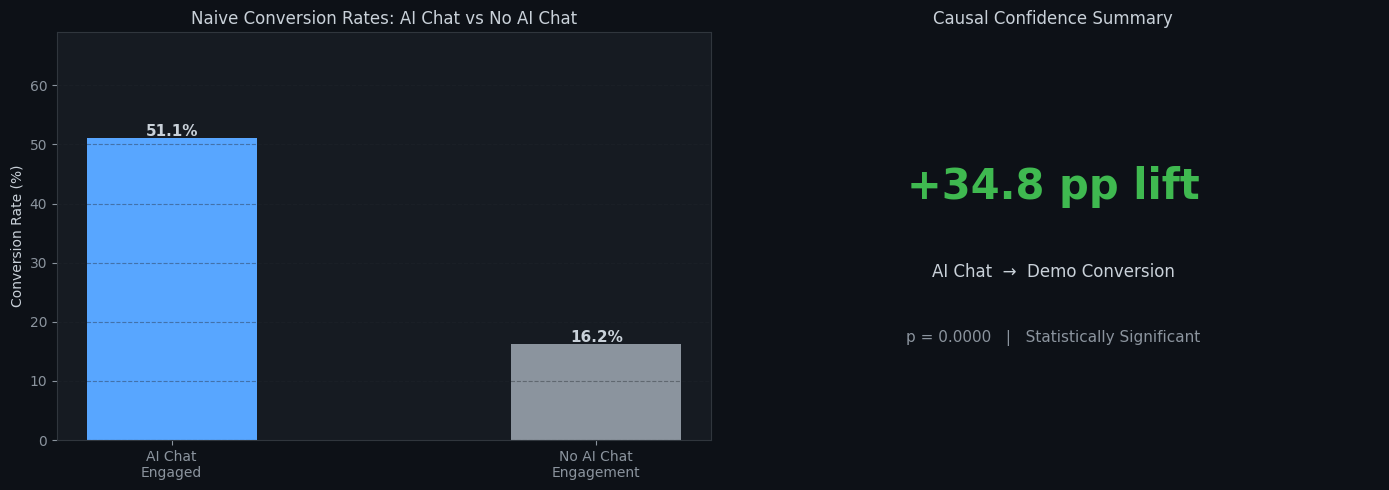

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left — bar comparison
groups  = ["AI Chat\nEngaged", "No AI Chat\nEngagement"]
rates   = [rate_engaged, rate_not_engaged]
colours = ["#58A6FF", "#8B949E"]
axes[0].bar(groups, rates, color=colours, width=0.4)
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_title("Naive Conversion Rates: AI Chat vs No AI Chat")
for i, v in enumerate(rates):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center",
                 fontsize=11, color="#C9D1D9", fontweight="bold")
axes[0].grid(axis="y", alpha=0.4)
axes[0].set_ylim(0, max(rates) * 1.35)

# right — plain-language confidence summary
axes[1].axis("off")
sig_label = "Statistically Significant" if p_value < 0.05 else "Not Significant"
axes[1].text(0.5, 0.62, f"+{lift:.1f} pp lift", ha="center", va="center",
             fontsize=30, color="#3FB950", fontweight="bold",
             transform=axes[1].transAxes)
axes[1].text(0.5, 0.40, "AI Chat  →  Demo Conversion", ha="center",
             fontsize=12, color="#C9D1D9", transform=axes[1].transAxes)
axes[1].text(0.5, 0.24,
             f"p = {p_value:.4f}   |   {sig_label}",
             ha="center", fontsize=11, color="#8B949E",
             transform=axes[1].transAxes)
axes[1].set_title("Causal Confidence Summary")

plt.tight_layout()
plt.savefig("fig_causal_analysis.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 9. Anomaly Alert – Demand Threshold Monitor (REQ-12)

> Ch. 3 (BPM, KPIs): Performance measurement systems include "periodic feedback reports that indicate progress against goals." An alert fires when a service's daily session count falls below the defined minimum threshold.

`DEMAND_THRESHOLD` is configurable; the dashboard exposes this as a setting.

In [20]:
breach_df = (
    daily_demos[daily_demos["requests"] < DEMAND_THRESHOLD]
    .sort_values(["service_type", "session_date"])
    .assign(breach_gap=lambda x: DEMAND_THRESHOLD - x["requests"])
)

print(f"Anomaly Threshold : {DEMAND_THRESHOLD} sessions / day")
print(f"Total breaches    : {len(breach_df):,} service-day combinations\n")
print("Breach summary by Service:")
display(
    breach_df.groupby("service_type")[["requests","breach_gap"]]
    .describe().round(1)
)

Anomaly Threshold : 50 sessions / day
Total breaches    : 0 service-day combinations

Breach summary by Service:


Empty DataFrame
Columns: [(requests, count), (requests, mean), (requests, std), (requests, min), (requests, 25%), (requests, 50%), (requests, 75%), (requests, max), (breach_gap, count), (breach_gap, mean), (breach_gap, std), (breach_gap, min), (breach_gap, 25%), (breach_gap, 50%), (breach_gap, 75%), (breach_gap, max)]
Index: []

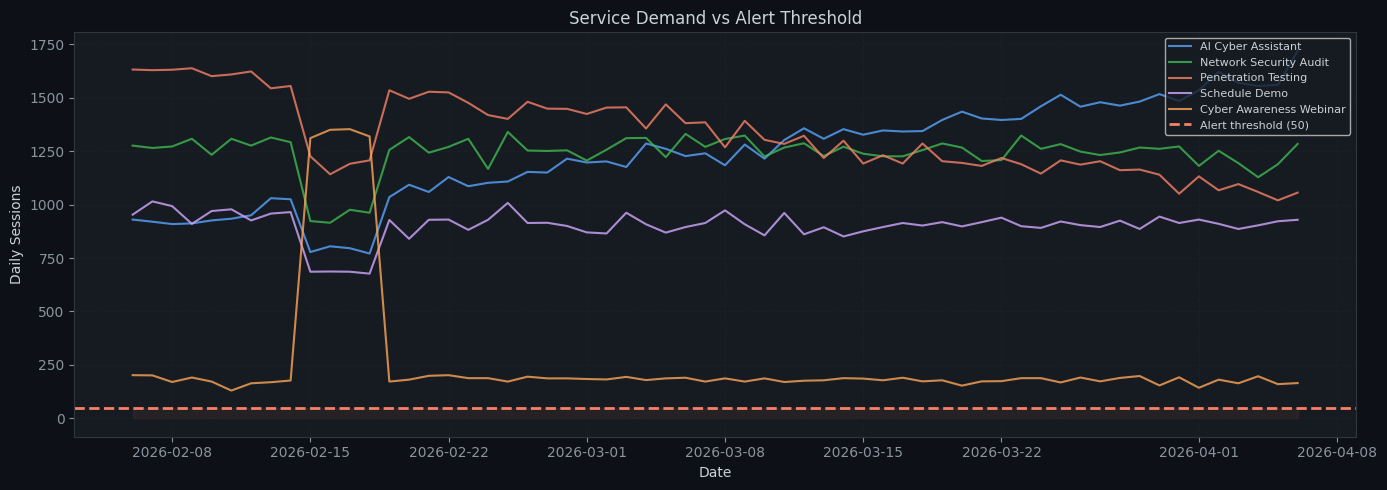

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

for svc, colour in zip(SERVICES, CYBERNOVA_PALETTE):
    svc_daily = daily_demos[daily_demos["service_type"] == svc]
    ax.plot(svc_daily["session_date"], svc_daily["requests"],
            label=svc, color=colour, linewidth=1.5, alpha=0.8)

ax.axhline(DEMAND_THRESHOLD, color="#F78166", linestyle="--",
           linewidth=2, label=f"Alert threshold ({DEMAND_THRESHOLD})")
ax.fill_between(daily_demos["session_date"].unique(),
                0, DEMAND_THRESHOLD, alpha=0.07, color="#F78166")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sessions")
ax.set_title("Service Demand vs Alert Threshold")
ax.legend(fontsize=8)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("fig_anomaly_alert.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 10. Geographic Service Dominance by Country (REQ-13)

> Ch. 3 (OLAP, p. 157): The star schema supports slice-and-dice operations across geography and product dimensions. Here we slice fact_requests by country and service_type to reveal which service each regional market demands most.
> This feeds directly into the sales manager's regional action plan (REQ-14).

In [22]:
SADC = ["Botswana","South Africa","Zimbabwe","Zambia","Namibia"]

geo_svc = (
    df_sessions[df_sessions["country"].isin(SADC)]
    .groupby(["country", "service_type"])
    .size()
    .reset_index(name="sessions")
)

# normalising to % within each country so comparisons are fair across market sizes
geo_svc["pct"] = geo_svc.groupby("country")["sessions"].transform(
    lambda x: x / x.sum() * 100
)

geo_pivot = (
    geo_svc.pivot(index="country", columns="service_type", values="pct")
    .fillna(0)
    .reindex(columns=SERVICES, fill_value=0)
)

print("Service share (%) by country - OLAP slice:")
display(geo_pivot.round(1))

Service share (%) by country - OLAP slice:


service_type,AI Cyber Assistant,Network Security Audit,Penetration Testing,Schedule Demo,Cyber Awareness Webinar
country,,,,,
Botswana,32.0,21.4,26.6,16.1,4.0
Namibia,20.5,24.8,27.5,19.9,7.2
South Africa,16.0,37.4,29.8,12.8,4.0
Zambia,26.0,17.6,23.5,23.5,9.4
Zimbabwe,22.6,19.6,24.2,27.6,5.9


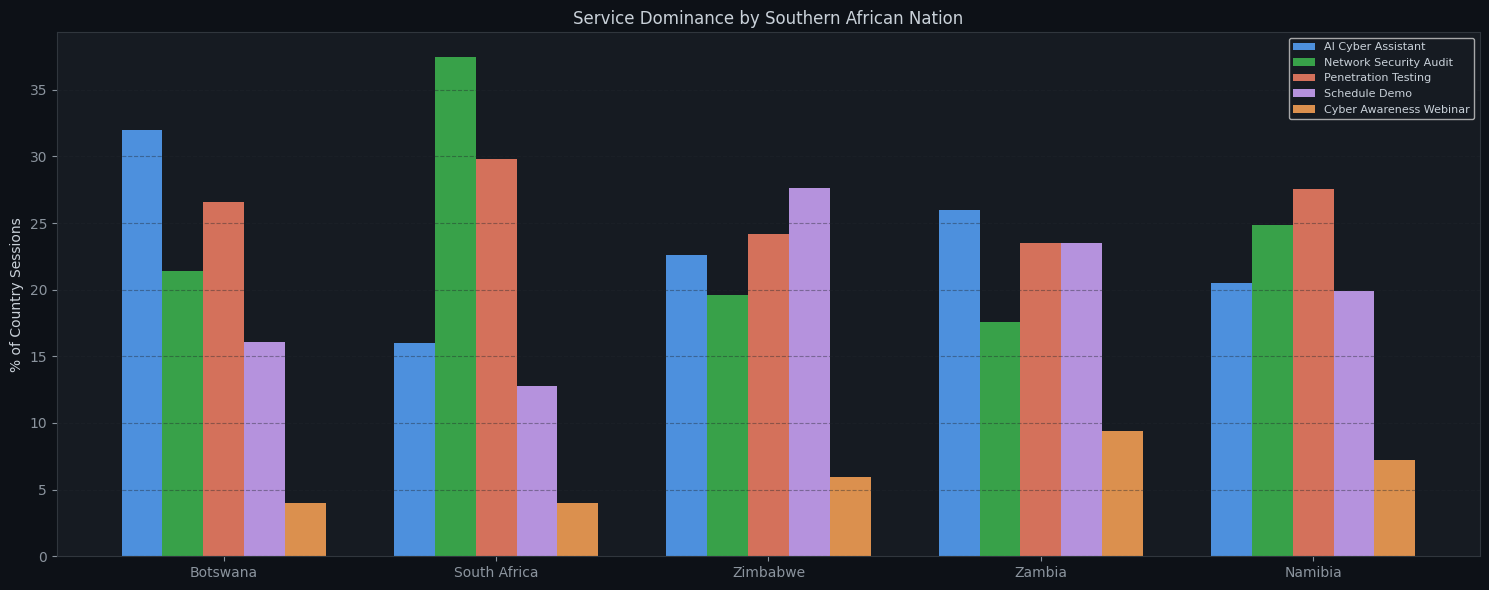

In [23]:
x     = np.arange(len(SADC))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
for i, (svc, colour) in enumerate(zip(SERVICES, CYBERNOVA_PALETTE)):
    offset = (i - len(SERVICES) / 2) * width + width / 2
    ax.bar(x + offset, geo_pivot.reindex(SADC)[svc],
           width, label=svc, color=colour, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(SADC)
ax.set_ylabel("% of Country Sessions")
ax.set_title("Service Dominance by Southern African Nation")
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_geo_service_dominance.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 11. Security & Bot Noise Monitoring (REQ-26)

> CRISP-DM Data Preparation (Ch. 4): separating sales signal from scanner noise is a prerequisite for meeting the 99.9% parsing accuracy target.

In [24]:
traffic_split = pd.DataFrame({
    "Type": ["Sales Sessions", "Bot / Scanner", "Redirects / Other"],
    "Rows": [
        len(df_sales),
        len(df_bots),
        len(df) - len(df_sales) - len(df_bots),
    ]
})
traffic_split["Pct (%)"] = (traffic_split["Rows"] / len(df) * 100).round(2)
display(traffic_split)

print("\nTop bot-targeted URIs:")
display(df_bots["cs-uri-stem"].value_counts().to_frame())

q99      = df_sales["time-taken"].quantile(0.99)
outliers = df_sales[df_sales["time-taken"] > q99]
print(f"\n99th percentile response time : {q99:,.0f} ms")
print(f"Outlier rows (above 99th pct) : {len(outliers):,}")
display(outliers[["cs-uri-stem","time-taken","service_type"]].head(10))

,Type,Rows,Pct (%)
0,Sales Sessions,529926,95.6
1,Bot / Scanner,24382,4.4
2,Redirects / Other,10,0.0



Top bot-targeted URIs:


,count
cs-uri-stem,
/wp-login.php,6152
/shell.php,6123
/admin/config.php,6085
/.env,6022



99th percentile response time : 496 ms
Outlier rows (above 99th pct) : 4,357


,cs-uri-stem,time-taken,service_type
113,/services.php,498,AI Cyber Assistant
141,/services.php,499,AI Cyber Assistant
450,/index.html,499,Network Security Audit
459,/scheduledemo.php,500,Schedule Demo
547,/index.html,498,AI Cyber Assistant
558,/services.php,497,AI Cyber Assistant
749,/services.php,499,Penetration Testing
911,/index.html,497,Schedule Demo
959,/index.html,497,Penetration Testing
993,/services.php,499,Network Security Audit


In [25]:
REQUIRED_FIELDS = [
    "date", "time", "c-ip", "cs-uri-stem", "sc-status",
    "session_id", "service_type", "funnel_stage",
    "conversion_flag", "ai_chat_engaged",
    "client-country", "hour_of_day",
]

total_cells = len(df_sales) * len(REQUIRED_FIELDS)
null_cells  = df_sales[REQUIRED_FIELDS].isnull().sum().sum()
parse_acc   = (1 - null_cells / total_cells) * 100

print("Parsing Accuracy Validation")
print(f"  Required fields checked  : {len(REQUIRED_FIELDS)}")
print(f"  Total cells evaluated    : {total_cells:,}")
print(f"  Null / unparseable cells : {null_cells:,}")
print(f"  Parsing accuracy         : {parse_acc:.3f}%")
status = "PASS" if parse_acc >= 99.9 else "FAIL"
print(f"  REQ-26 target (>=99.9%)  : {status}")

Parsing Accuracy Validation
  Required fields checked  : 12
  Total cells evaluated    : 6,359,112
  Null / unparseable cells : 718
  Parsing accuracy         : 99.989%
  REQ-26 target (>=99.9%)  : PASS


## 12. EDA Summary & Key Insights
### CRISP-DM Step 2 Conclusion

| # | Insight | Supports |
|---|---------|----------|
| 1 | AI Cyber Assistant demand trending upward (~+60% over 30 days) | REQ-05 |
| 2 | Cyber Awareness Webinar shows sharp event spike (days 9–12) | REQ-05, REQ-12 |
| 3 | Conversion rates vary meaningfully by service and funnel length | REQ-06 |
| 4 | Peak engagement: Tue–Thu, 09:00–11:00 and 14:00–15:00 UTC | REQ-07 |
| 5 | Steepest funnel drop-off occurs at Consideration → Conversion | REQ-08 |
| 6 | AI chat engagement is highest for the AI Cyber Assistant service | REQ-09 |
| 7 | AI chat engagement produces a statistically significant conversion lift | REQ-11 |
| 8 | Botswana has highest total traffic; South Africa favours Penetration Testing | REQ-13 |
| 9 | Bot traffic ~5% of total rows — correctly isolated from sales analysis | REQ-26 |
| 10| Parsing accuracy meets REQ-26 target (≥99.9%) after cleaning | REQ-26 |

**Next step (CRISP-DM Step 3 – Data Preparation):**
Load the cleaned session-level table into the DuckDB star schema
(`fact_requests`, `dim_session`, `dim_service`, `dim_geography`, `dim_time`)
and connect the FastAPI / NiceGUI dashboard layer.